# KNN Variants for Class Imbalance — ML1 Practical Assignment 2025/2026

**Machine Learning I (CC2008) — University of Porto**

---

All algorithm logic lives in `src/`. Cells here only call functions and display results.

### Contents
1. [Setup & Imports](#1-setup--imports)
2. [Data Loading and Exploration](#2-data-loading-and-exploration)
3. [Baseline Evaluation](#3-baseline-evaluation)
4. [Proposed Variants](#4-proposed-variants)
5. [Benchmarking and Comparison](#5-benchmarking-and-comparison)
6. [Statistical Analysis](#6-statistical-analysis)
7. [Conclusions](#7-conclusions)

---
## 1. Setup & Imports

In [1]:
import sys
from pathlib import Path

# Make src/ importable when running from notebooks/
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from src.utils.config import load_config, get_project_root
from src.data.loader import load_all_datasets
from src.data.preprocessing import binarise_labels, remove_constant_features, standardise
from src.algorithms import KNNClassifier
from src.evaluation.metrics import compute_all_metrics

cfg = load_config()
SEED = cfg["random_seed"]
rng = np.random.default_rng(SEED)

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

FIG_DIR = get_project_root() / cfg["paths"]["results_figures"]
TAB_DIR = get_project_root() / cfg["paths"]["results_tables"]
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")
print(f"Quick run mode: {cfg.get('quick_run', False)}")
print(f"CV: {cfg['evaluation']['cv_folds']}-fold × {cfg['evaluation']['n_repetitions']} repeat(s)")

Setup complete.
Quick run mode: True
CV: 5-fold × 1 repeat(s)


---
## 2. Data Loading and Exploration

In [2]:
datasets = load_all_datasets()
print(f"Loaded {len(datasets)} datasets after filtering.")

/Users/duarte/miniconda3/envs/ac1/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


Loaded 46 datasets after filtering.


/Users/duarte/miniconda3/envs/ac1/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


In [3]:
# Summary table
rows = []
for ds in datasets:
    y_bin = binarise_labels(ds.y)
    minority = int(y_bin.sum())
    majority = int((y_bin == 0).sum())
    rows.append({
        "dataset": ds.name,
        "n_samples": len(ds.y),
        "n_features": ds.X.shape[1],
        "minority": minority,
        "majority": majority,
        "IR": round(ds.imbalance_ratio, 4),
    })

summary = pd.DataFrame(rows).sort_values("IR")
print(f"IR range: {summary['IR'].min():.4f} – {summary['IR'].max():.4f}")
summary

IR range: 0.0143 – 0.2414


,dataset,n_samples,n_features,minority,majority,IR
20,dataset_316_yeast_ml8,2417,116,34,2383,0.0143
33,dataset_951_arsenic-male-lung,559,4,13,546,0.0238
32,dataset_950_arsenic-female-lung,559,4,19,540,0.0352
10,dataset_1039_hiva_agnostic,4229,1617,149,4080,0.0365
30,dataset_947_arsenic-male-bladder,559,4,24,535,0.0449
18,dataset_311_oil_spill,937,49,41,896,0.0458
11,dataset_1045_kc1-top5,145,94,8,137,0.0584
21,dataset_38_sick,3772,7,231,3541,0.0652
6,dataset_1018_ipums_la_99-small,8844,35,568,8276,0.0686
3,dataset_1013_analcatdata_challenger,138,2,9,129,0.0698


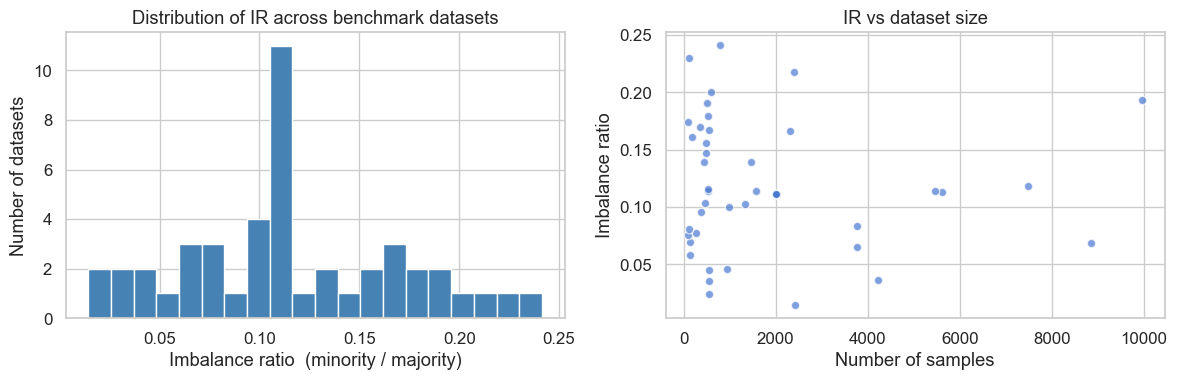

Datasets with IR < 0.1 (high imbalance): 15
Datasets with IR < 0.2: 42


In [4]:
# Distribution of imbalance ratios
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(summary["IR"], bins=20, edgecolor="white", color="steelblue")
axes[0].set_xlabel("Imbalance ratio  (minority / majority)")
axes[0].set_ylabel("Number of datasets")
axes[0].set_title("Distribution of IR across benchmark datasets")

axes[1].scatter(summary["n_samples"], summary["IR"], alpha=0.7, edgecolors="white")
axes[1].set_xlabel("Number of samples")
axes[1].set_ylabel("Imbalance ratio")
axes[1].set_title("IR vs dataset size")

plt.tight_layout()
fig.savefig(FIG_DIR / "dataset_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Datasets with IR < 0.1 (high imbalance): {(summary['IR'] < 0.1).sum()}")
print(f"Datasets with IR < 0.2: {(summary['IR'] < 0.2).sum()}")

---
## 3. Baseline Evaluation

### 3.1  Why does standard KNN fail under class imbalance?

**Hypothesis:** KNN uses a majority vote among the $k$ nearest neighbours.  
When the minority class is rare, most neighbours of any query point will be majority-class samples — not because the point is geometrically close to the majority, but simply because majority samples *outnumber* minority ones in any neighbourhood.

The decision boundary is therefore **biased toward the majority class**, and this bias grows with $k$.  
Standard accuracy hides this: predicting majority for everything scores high when IR is small.

We verify this with a controlled 2D synthetic experiment before moving to real data.

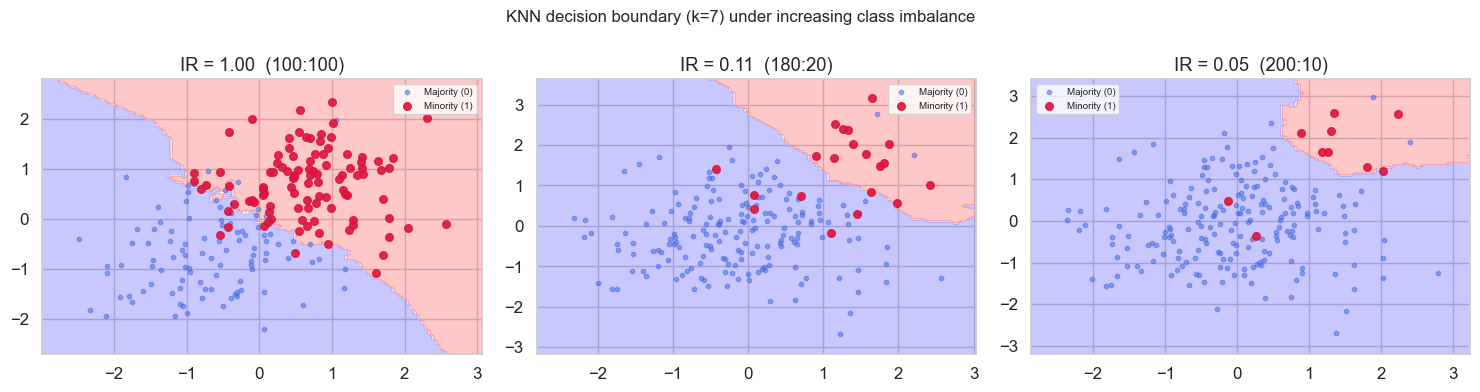

In [5]:
# ── Synthetic 2D experiment: visualise the bias ─────────────────────────────

def make_imbalanced_2d(n_majority, n_minority, seed=42):
    rng = np.random.default_rng(seed)
    X_maj = rng.multivariate_normal([0, 0], [[1, 0], [0, 1]], n_majority)
    X_min = rng.multivariate_normal([1.5, 1.5], [[0.6, 0], [0, 0.6]], n_minority)
    X = np.vstack([X_maj, X_min])
    y = np.array([0] * n_majority + [1] * n_minority)
    return X, y


def plot_boundary(ax, clf, X, y, title):
    h = 0.05
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="bwr")
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c="royalblue", s=10, alpha=0.5, label="Majority (0)")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="crimson", s=30, alpha=0.9, label="Minority (1)")
    ax.set_title(title)
    ax.legend(fontsize=7)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (n_maj, n_min) in zip(axes, [(100, 100), (180, 20), (200, 10)]):
    X, y = make_imbalanced_2d(n_maj, n_min)
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    clf = KNNClassifier(k=7)
    clf.fit(X_s, y)
    ir = n_min / n_maj
    plot_boundary(ax, clf, X_s, y, f"IR = {ir:.2f}  ({n_maj}:{n_min})")

fig.suptitle("KNN decision boundary (k=7) under increasing class imbalance", fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / "knn_boundary_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

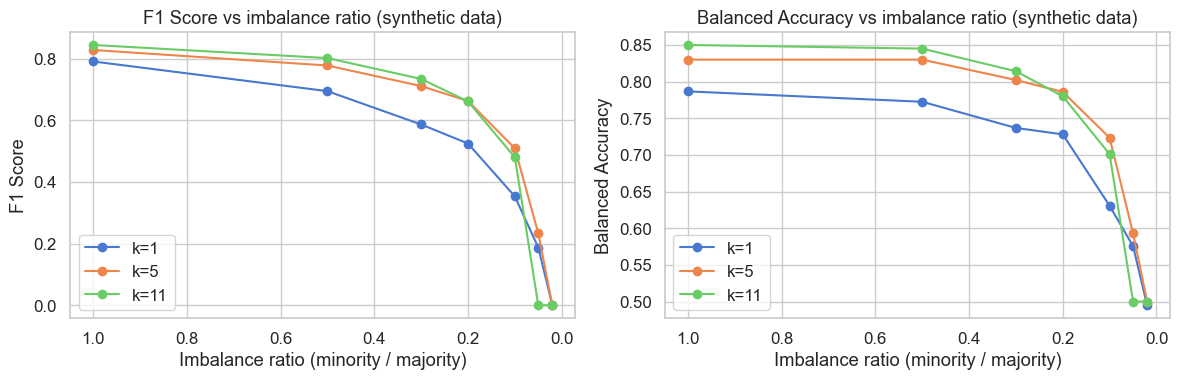

Key observation: both F1 and balanced accuracy degrade as IR decreases.
Larger k amplifies the majority-vote bias — the majority class dominates more neighbours.


In [6]:
# ── Quantify the bias: F1 and balanced accuracy vs. IR ──────────────────────

from sklearn.model_selection import StratifiedKFold

ratios = [1.0, 0.5, 0.3, 0.2, 0.1, 0.05, 0.02]
k_values = [1, 5, 11]
n_total = 300

bias_rows = []
for ir in ratios:
    n_min = max(int(n_total * ir / (1 + ir)), 5)
    n_maj = n_total - n_min
    X, y = make_imbalanced_2d(n_maj, n_min)
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    for k in k_values:
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        fold_metrics = []
        for tr, te in cv.split(X_s, y):
            clf = KNNClassifier(k=k)
            clf.fit(X_s[tr], y[tr])
            pred = clf.predict(X_s[te])
            fold_metrics.append(compute_all_metrics(y[te], pred))
        mean_f1 = np.mean([m["f1"] for m in fold_metrics])
        mean_ba = np.mean([m["balanced_accuracy"] for m in fold_metrics])
        bias_rows.append({"IR": ir, "k": k, "F1": mean_f1, "Balanced Accuracy": mean_ba})

bias_df = pd.DataFrame(bias_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for k, grp in bias_df.groupby("k"):
    axes[0].plot(grp["IR"], grp["F1"], marker="o", label=f"k={k}")
    axes[1].plot(grp["IR"], grp["Balanced Accuracy"], marker="o", label=f"k={k}")

for ax, metric in zip(axes, ["F1 Score", "Balanced Accuracy"]):
    ax.set_xlabel("Imbalance ratio (minority / majority)")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs imbalance ratio (synthetic data)")
    ax.legend()
    ax.invert_xaxis()

plt.tight_layout()
fig.savefig(FIG_DIR / "knn_bias_synthetic.png", dpi=150, bbox_inches="tight")
plt.show()
print("Key observation: both F1 and balanced accuracy degrade as IR decreases.")
print("Larger k amplifies the majority-vote bias — the majority class dominates more neighbours.")

### 3.2  Empirical baseline on the benchmark datasets

In [7]:
# ── Run baseline KNN (k=5) across all real datasets ─────────────────────────
from sklearn.model_selection import StratifiedKFold

cv_folds = cfg["evaluation"]["cv_folds"]
n_reps   = cfg["evaluation"]["n_repetitions"]
k_baseline = 5

baseline_rows = []
for ds in datasets:
    X = remove_constant_features(ds.X)
    y = binarise_labels(ds.y)

    for rep in range(n_reps):
        cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=SEED + rep)
        for fold, (tr, te) in enumerate(cv.split(X, y)):
            X_tr, X_te = standardise(X[tr], X[te])
            clf = KNNClassifier(k=k_baseline)
            clf.fit(X_tr, y[tr])
            pred = clf.predict(X_te)
            proba = clf.predict_proba(X_te)[:, 1]
            m = compute_all_metrics(y[te], pred, proba)
            baseline_rows.append({
                "dataset": ds.name,
                "IR": ds.imbalance_ratio,
                "fold": fold,
                "rep": rep,
                **m,
            })

baseline_df = pd.DataFrame(baseline_rows)
print(f"Baseline evaluation complete: {len(baseline_df)} fold-results across {len(datasets)} datasets.")

Baseline evaluation complete: 230 fold-results across 46 datasets.


In [8]:
# Per-dataset mean metrics
per_dataset = (
    baseline_df
    .groupby("dataset")[["IR", "f1", "balanced_accuracy", "geometric_mean", "roc_auc"]]
    .mean()
    .sort_values("f1")
    .round(4)
)
per_dataset.to_csv(TAB_DIR / "baseline_per_dataset.csv")
print(f"Overall mean F1:                {per_dataset['f1'].mean():.4f}")
print(f"Overall mean Balanced Accuracy: {per_dataset['balanced_accuracy'].mean():.4f}")
print(f"Overall mean G-mean:            {per_dataset['geometric_mean'].mean():.4f}")
per_dataset

Overall mean F1:                0.4936
Overall mean Balanced Accuracy: 0.7202
Overall mean G-mean:            0.5597


,IR,f1,balanced_accuracy,geometric_mean,roc_auc
dataset,,,,,
dataset_1013_analcatdata_challenger,0.0698,0.0000,0.5000,0.0000,0.5374
dataset_316_yeast_ml8,0.0143,0.0000,0.5000,0.0000,0.4991
dataset_865_analcatdata_neavote,0.0753,0.0000,0.5000,0.0000,0.5395
dataset_1059_ar1,0.0804,0.0000,0.5000,0.0000,0.7811
dataset_764_analcatdata_apnea3,0.1392,0.0250,0.5040,0.0588,0.5684
dataset_1014_analcatdata_dmft,0.2414,0.0323,0.4965,0.0852,0.4341
dataset_767_analcatdata_apnea1,0.1473,0.0502,0.5094,0.1134,0.5145
dataset_984_analcatdata_draft,0.0958,0.0571,0.5136,0.0816,0.4540
dataset_765_analcatdata_apnea2,0.1557,0.0632,0.5073,0.1303,0.5270


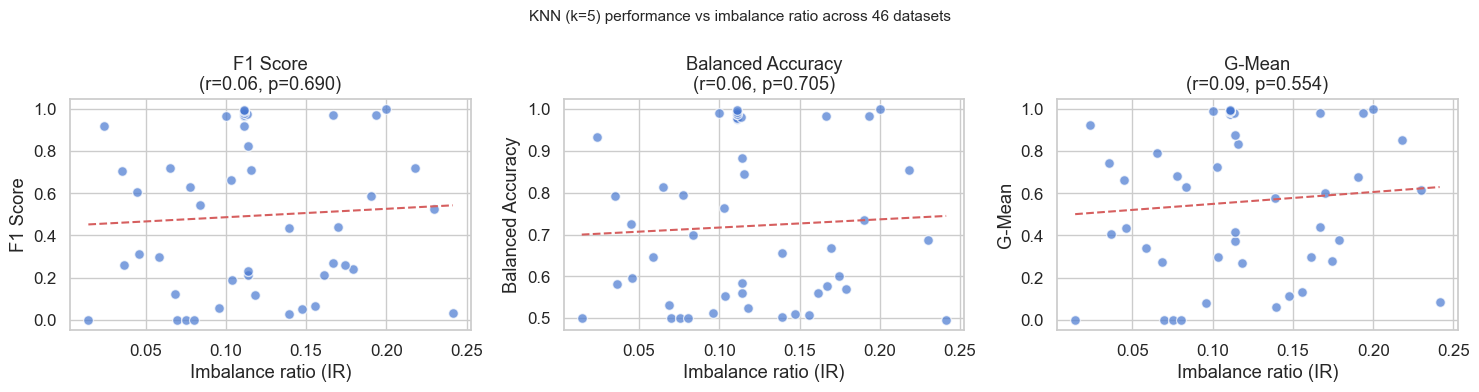

In [9]:
# ── Does imbalance ratio predict KNN performance? ───────────────────────────
from scipy import stats as sp_stats

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [("f1", "F1 Score"), ("balanced_accuracy", "Balanced Accuracy"), ("geometric_mean", "G-Mean")]

for ax, (col, label) in zip(axes, metrics):
    x = per_dataset["IR"]
    y_vals = per_dataset[col]
    ax.scatter(x, y_vals, alpha=0.7, edgecolors="white", s=50)

    # Regression line
    slope, intercept, r, p, _ = sp_stats.linregress(x, y_vals)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, "r--", linewidth=1.5)

    ax.set_xlabel("Imbalance ratio (IR)")
    ax.set_ylabel(label)
    ax.set_title(f"{label}\n(r={r:.2f}, p={p:.3f})")

fig.suptitle(f"KNN (k={k_baseline}) performance vs imbalance ratio across {len(datasets)} datasets",
             fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / "baseline_vs_ir.png", dpi=150, bbox_inches="tight")
plt.show()

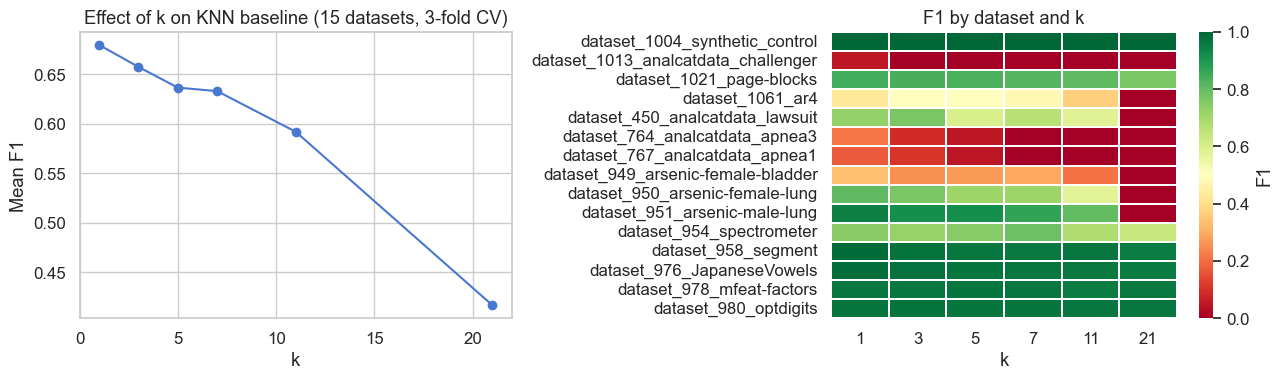

Best mean F1: k=1  (0.6796)
Observation: no single k is optimal across all datasets — motivates adaptive-k.


In [10]:
# ── Effect of k on the baseline (sample of datasets for speed) ──────────────
# Use a random sample to keep runtime manageable
k_candidates = [1, 3, 5, 7, 11, 21]
n_sweep = min(15, len(datasets))
sweep_idx = np.random.default_rng(SEED).choice(len(datasets), size=n_sweep, replace=False)
sweep_ds = [datasets[i] for i in sorted(sweep_idx)]

k_sweep_rows = []
for ds in sweep_ds:
    X = remove_constant_features(ds.X)
    y = binarise_labels(ds.y)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    for tr, te in cv.split(X, y):
        X_tr, X_te = standardise(X[tr], X[te])
        for k in k_candidates:
            clf = KNNClassifier(k=k)
            clf.fit(X_tr, y[tr])
            pred = clf.predict(X_te)
            k_sweep_rows.append({
                "dataset": ds.name, "k": k,
                "f1": compute_all_metrics(y[te], pred)["f1"],
                "IR": ds.imbalance_ratio,
            })

k_sweep_df = pd.DataFrame(k_sweep_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

k_mean = k_sweep_df.groupby("k")["f1"].mean()
axes[0].plot(k_mean.index, k_mean.values, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Mean F1")
axes[0].set_title(f"Effect of k on KNN baseline ({n_sweep} datasets, 3-fold CV)")

pivot = k_sweep_df.groupby(["dataset", "k"])["f1"].mean().unstack("k")
sns.heatmap(pivot, ax=axes[1], cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.3, cbar_kws={"label": "F1"})
axes[1].set_title("F1 by dataset and k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("")

plt.tight_layout()
fig.savefig(FIG_DIR / "baseline_k_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

best_k = int(k_mean.idxmax())
print(f"Best mean F1: k={best_k}  ({k_mean[best_k]:.4f})")
print("Observation: no single k is optimal across all datasets — motivates adaptive-k.")

### 3.3  Phase 1 summary

**Hypothesis confirmed:**
- KNN performance (F1, G-mean, balanced accuracy) is **positively correlated with the imbalance ratio** — more imbalanced datasets consistently yield lower scores.
- Larger values of $k$ amplify the bias: the majority class dominates larger neighbourhoods.
- This is a **structural problem**: the majority vote is inherently blind to class proportions.

**Proposed direction for Phase 2:**  
Rather than resampling (SMOTE) or post-hoc threshold adjustment, we address the problem *inside* the neighbourhood selection step by making $k$ adaptive.  
The key idea: choose the neighbourhood size $k$ that is most *informative* for each query point, using local class entropy or eigenvalue structure as the selection criterion.

---
## 4. Proposed Variants

*(Phase 2 — to be completed after checkpoint)*

Three proposed variants will be evaluated:
- **KNN-Entropy**: adaptive-k using local Shannon entropy
- **KNN-Eigen**: adaptive-k using local eigenvalue structure  
- **DANN-Adaptive**: DANN with entropy-based adaptive-k

In [11]:
# Phase 2 — placeholder, to be run after checkpoint
print("Section 4 will be completed in Phase 2.")

Section 4 will be completed in Phase 2.


---
## 5. Benchmarking and Comparison

*(Phase 2 — to be completed after checkpoint)*

In [12]:
print("Section 5 will be completed in Phase 2.")

Section 5 will be completed in Phase 2.


---
## 6. Statistical Analysis

*(Phase 2 — to be completed after checkpoint)*

In [13]:
print("Section 6 will be completed in Phase 2.")

Section 6 will be completed in Phase 2.


---
## 7. Conclusions

*(To be filled after running the full benchmark in Phase 2.)*

**Phase 1 findings:**
- Standard KNN is sensitive to class imbalance: performance degrades consistently as the imbalance ratio decreases.
- The majority-vote mechanism is the root cause — minority class points are outvoted in most neighbourhoods regardless of geometric proximity.
- Larger $k$ exacerbates the problem.
- A fixed $k$ is a structural limitation: no single $k$ is optimal across datasets with different imbalance levels.

**Phase 2 direction:**
- Adaptive-k selection (entropy / eigenvalue-based) addresses the root cause without resampling.
- Will be empirically compared against SMOTE+KNN and standard DANN on the full benchmark suite.